In [2]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
print(sns.get_dataset_names()) #get builtin dataset names

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [4]:
df = sns.load_dataset('tips') #load dataset
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [5]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [6]:
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='str')

In [7]:
df['smoker'].value_counts()

smoker
No     151
Yes     93
Name: count, dtype: int64

*seaborn themes*

In [22]:
sns.set_theme(style="dark")

#### Distribution Plots

***1. Histogram***

Shows frequency distribution.

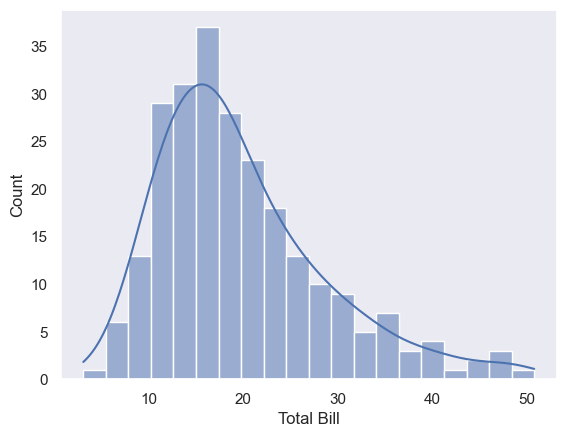

In [ ]:
sns.histplot(data = df , x = 'total_bill',bins = 20 , kde = True) #kde = kernel density estimation - it is a curve used to visualize the probability distribution of a continuous variable
plt.show()

***2. KDE Plot***

Shows probability density.

<Axes: xlabel='total_bill', ylabel='Density'>

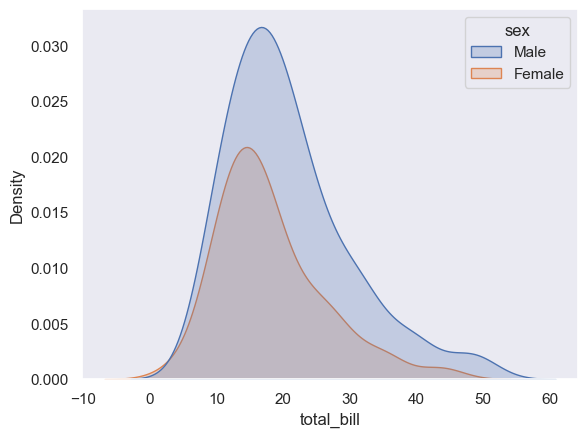

In [30]:
sns.kdeplot(
    data = df,
    x = 'total_bill',
    hue = 'sex',
    fill = True

)

***3 .Rug plot***

displays the distribution of a single quantitative variable along an axis using small, evenly spaced tick marks

<Axes: xlabel='total_bill'>

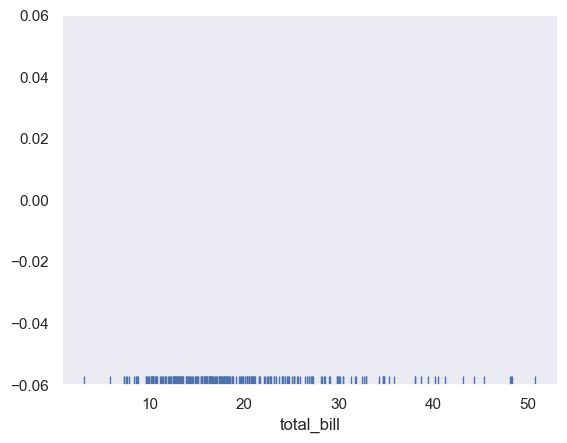

In [33]:
sns.rugplot(
    data = df,
    x = 'total_bill'
)

#### Categorical Plots

***4. Count Plot***

Counts category frequency.

<Axes: xlabel='smoker', ylabel='count'>

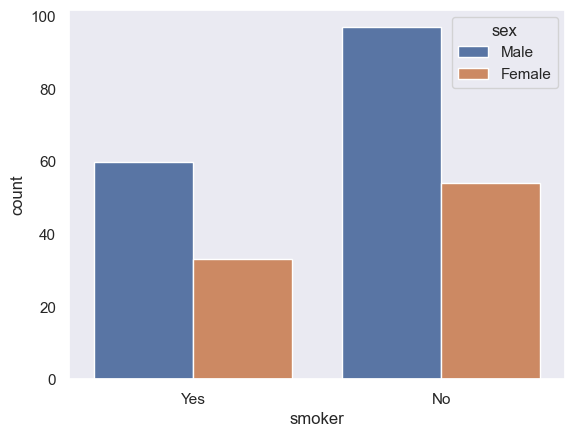

In [36]:
sns.countplot(
    data = df,
    x = "smoker",
    hue = 'sex'
)

***5. Bar Plot***

Shows aggregated value.

<Axes: xlabel='day', ylabel='total_bill'>

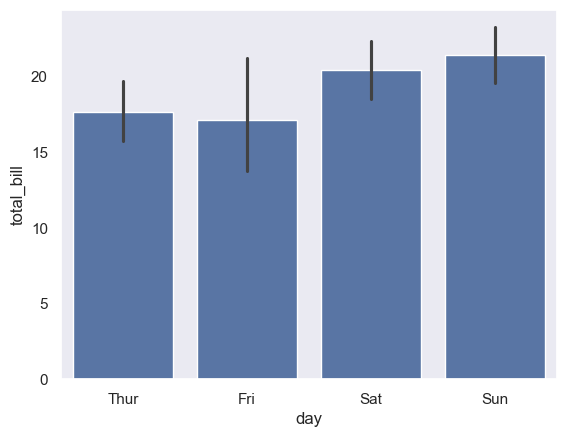

In [41]:
sns.barplot(
    data = df,
    x = 'day',
    y = 'total_bill',
)

***6. Box Plot***

Purpose: detect mean , quartiles and outliers

<Axes: xlabel='total_bill', ylabel='day'>

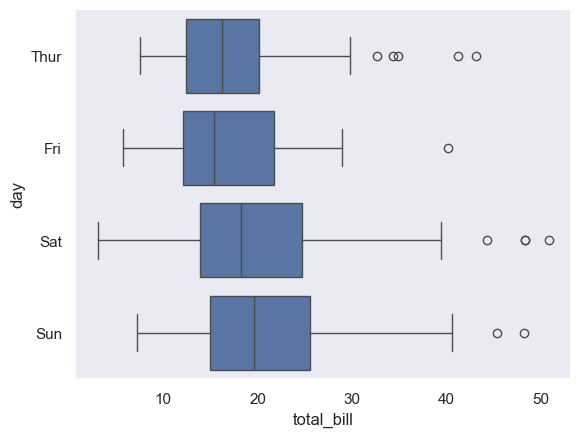

In [44]:
sns.boxplot(
    data = df,
    x='total_bill',
    y="day"
)

In [45]:
df["total_bill"].describe()

count    244.000000
mean      19.785943
std        8.902412
min        3.070000
25%       13.347500
50%       17.795000
75%       24.127500
max       50.810000
Name: total_bill, dtype: float64

group comparision

<Axes: xlabel='day', ylabel='total_bill'>

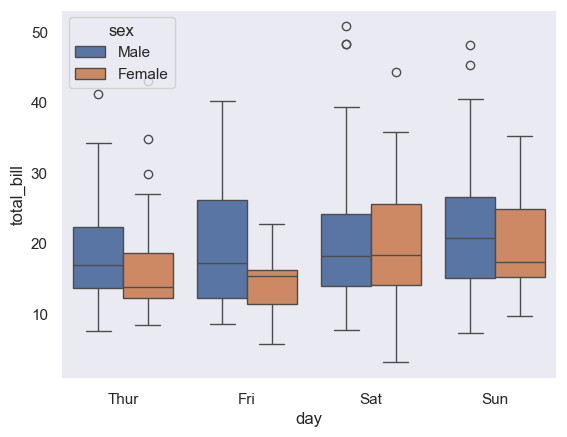

In [46]:
sns.boxplot(
    data=df,
    x="day",
    y="total_bill",
    hue="sex"
)

***7. Violin Plot***

Boxplot + Distribution

<Axes: xlabel='day', ylabel='total_bill'>

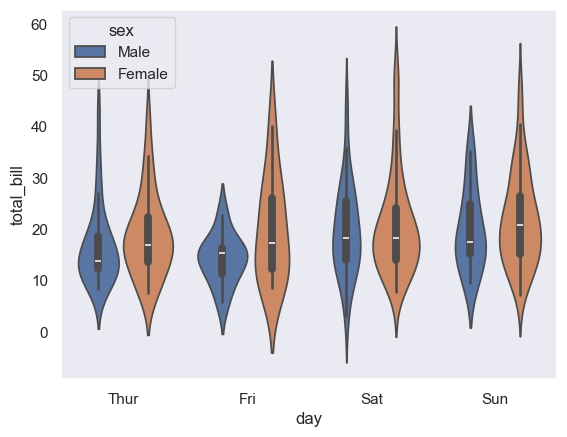

In [51]:
sns.violinplot(
    data = df,
    x = "day",
    y = "total_bill",
    hue = "sex"
)

***8. Strip Plot***

Shows every observation.

<Axes: xlabel='day', ylabel='total_bill'>

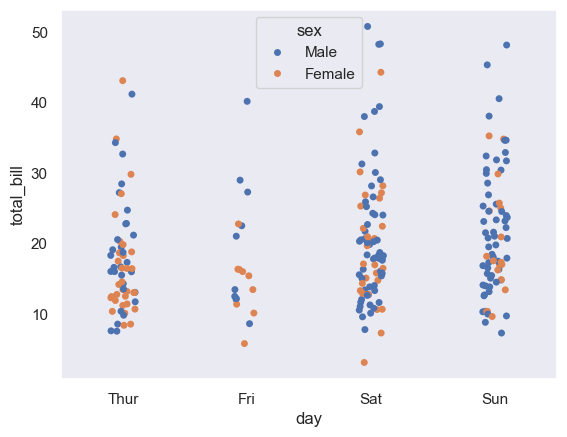

In [55]:
sns.stripplot(
    data = df,
    x = "day",
    y = "total_bill",
    hue = "sex",
    jitter = True #jitter - avoid overlapping
    )

***9. Swarm Plot***

Better version of strip plot.

<Axes: xlabel='day', ylabel='total_bill'>

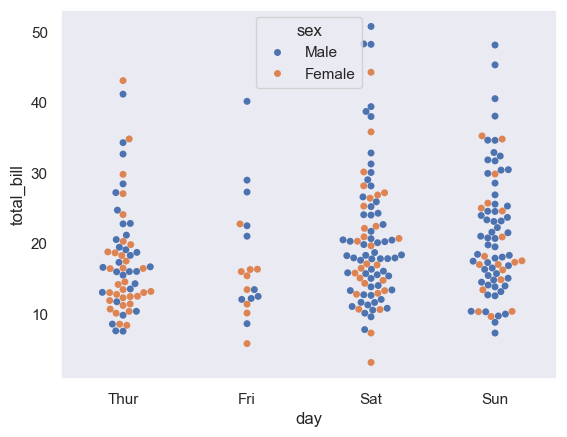

In [56]:
sns.swarmplot(
    data = df,
    x = "day",
    y = "total_bill",
    hue = "sex"
)

the above plot has no overlapping unlike stripplot with jitter

#### Relationship Plots

***10. Scatter Plot***

Relationship between variables.

<Axes: xlabel='day', ylabel='total_bill'>

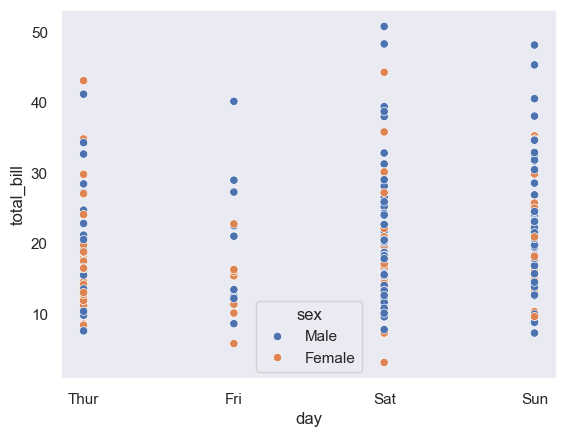

In [67]:
sns.scatterplot(
    data = df,
    x = "day",
    y = "total_bill",
    hue = "sex",
)

***11. Line Plot***

<Axes: xlabel='day', ylabel='total_bill'>

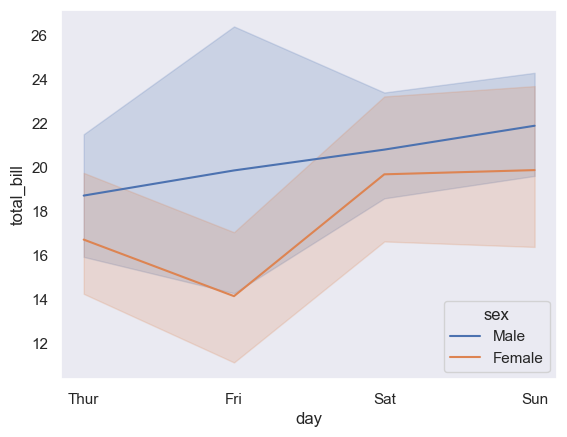

In [77]:
sns.lineplot(
    data = df,
    x = "day",
    y = "total_bill",
    hue = "sex"

)

#### Regression Plots

***12. Regplot***

Scatter + Regression Line

<Axes: xlabel='total_bill', ylabel='tip'>

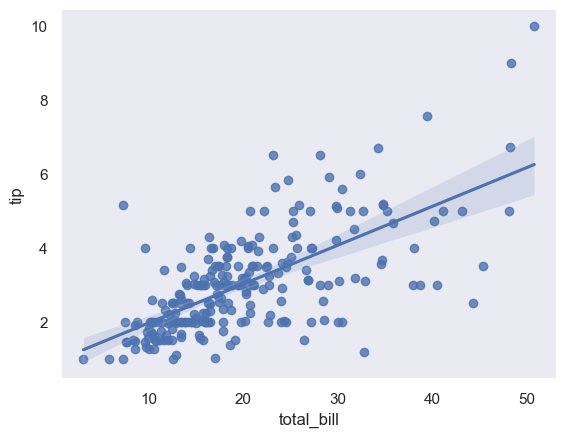

In [78]:
sns.regplot(
    data = df,
    x = "total_bill",
    y = "tip"
)

***13. Lmplot***

advanced regression plot

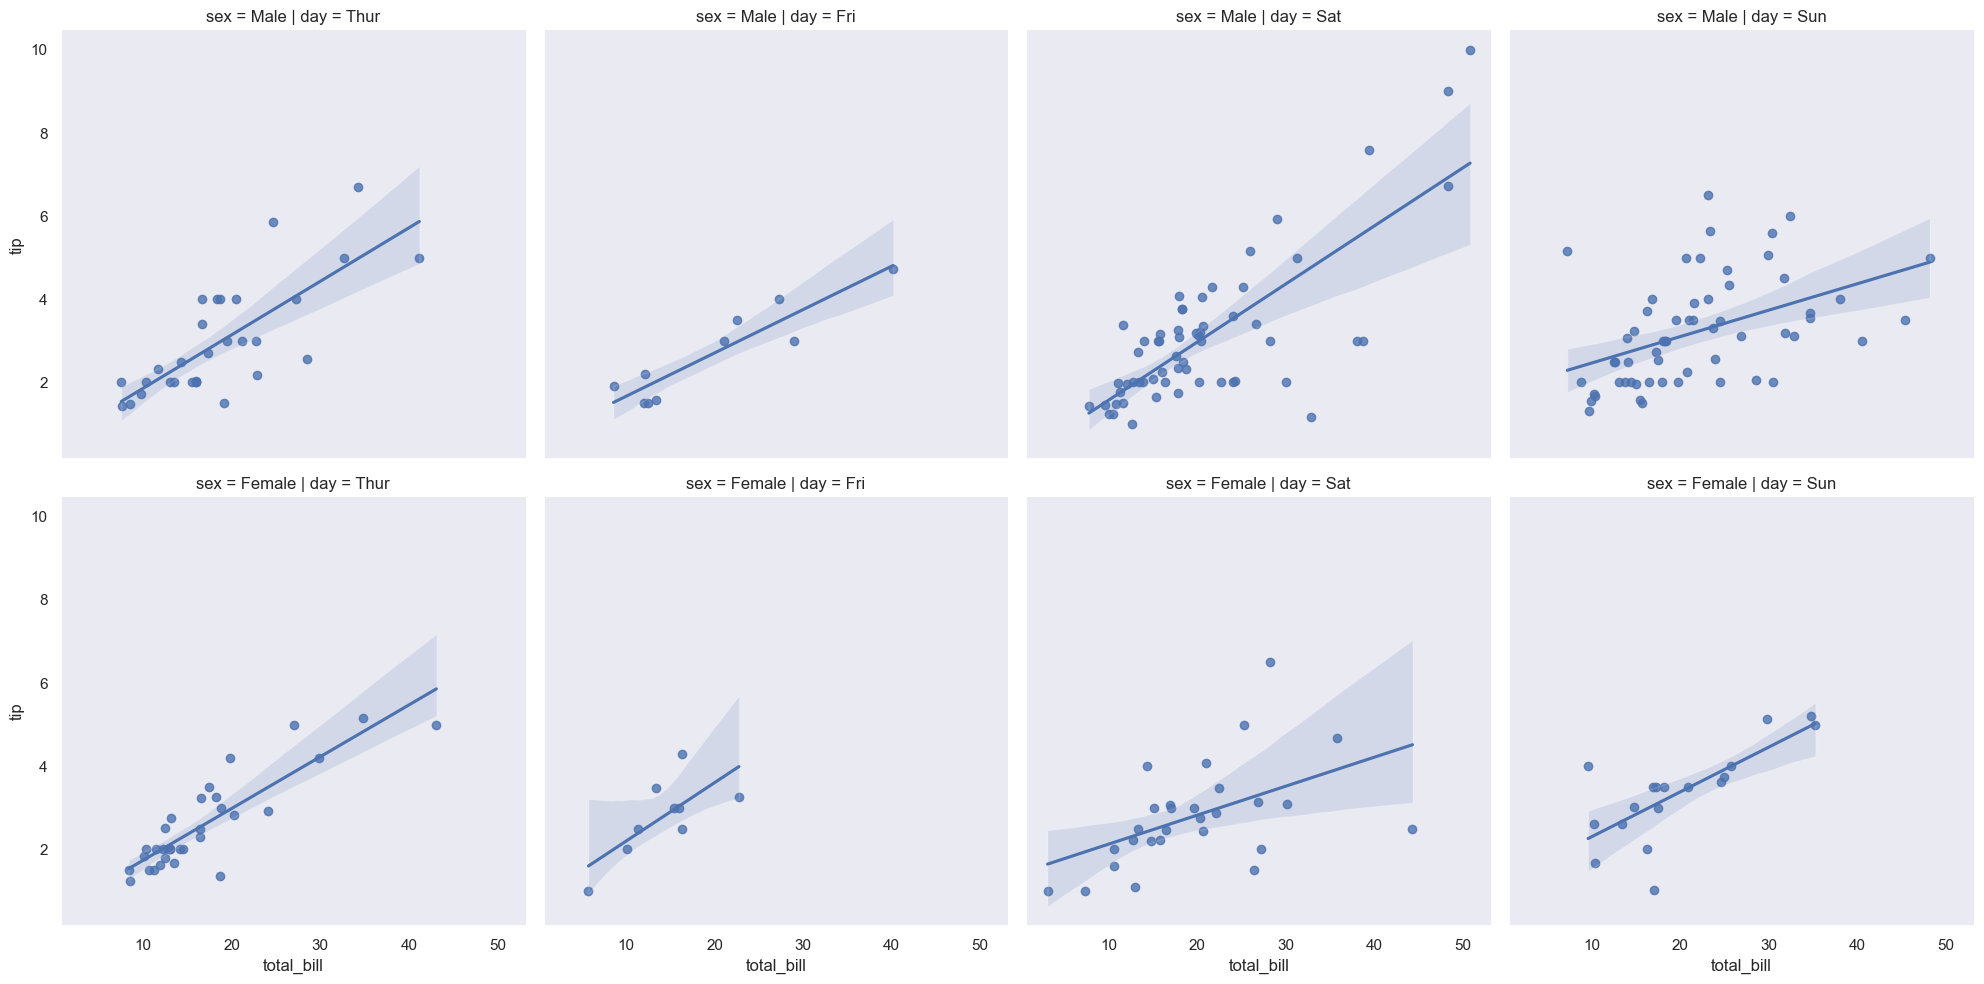

In [87]:
sns.lmplot(
    data = df,
    x = "total_bill",
    y = "tip",
    col = "day",
    row = "sex"
)

in the above graphs ; col and row are used to create subgraphs

#### Matrix Plots

***14. Heatmap***

A heatmap is a graphical representation of data where individual values are represented by color intensity.

<Axes: >

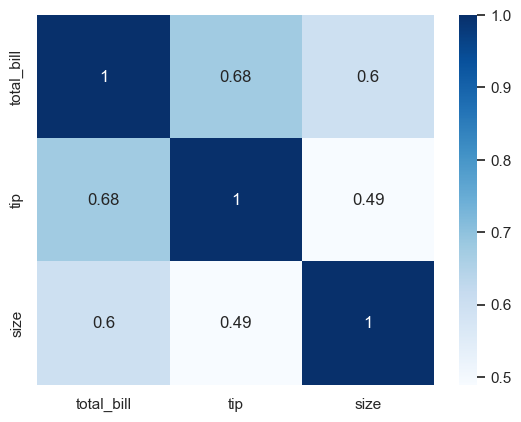

In [93]:
corr = df.corr(numeric_only=True)
sns.heatmap(
    data = corr,
    annot = True,
    cmap = "Blues"
)

***15. Clustermap***

Groups similar rows/columns.

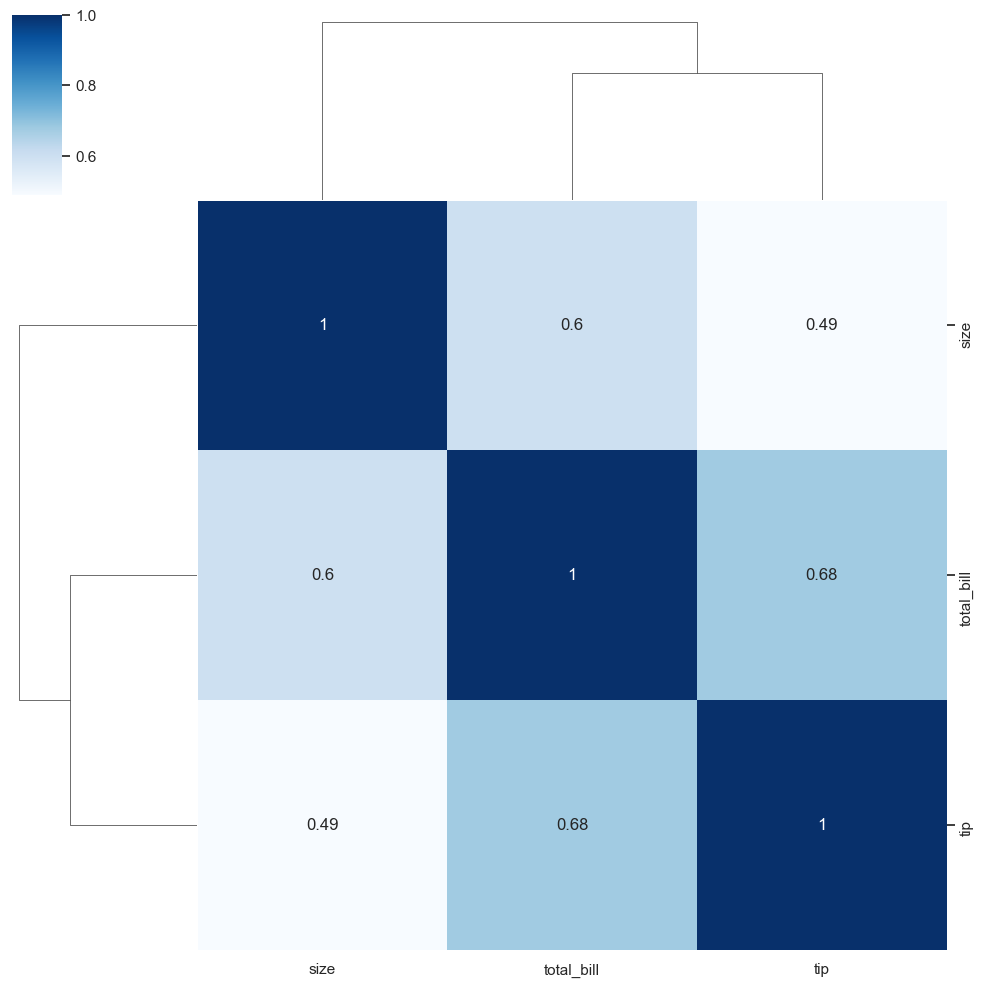

In [94]:
sns.clustermap(
    data = corr,
    annot = True,
    cmap = "Blues")

#### Multi-Variable Visualization

***16. Pair Plot***

 used for visualizing relationships between multiple variables in a dataset

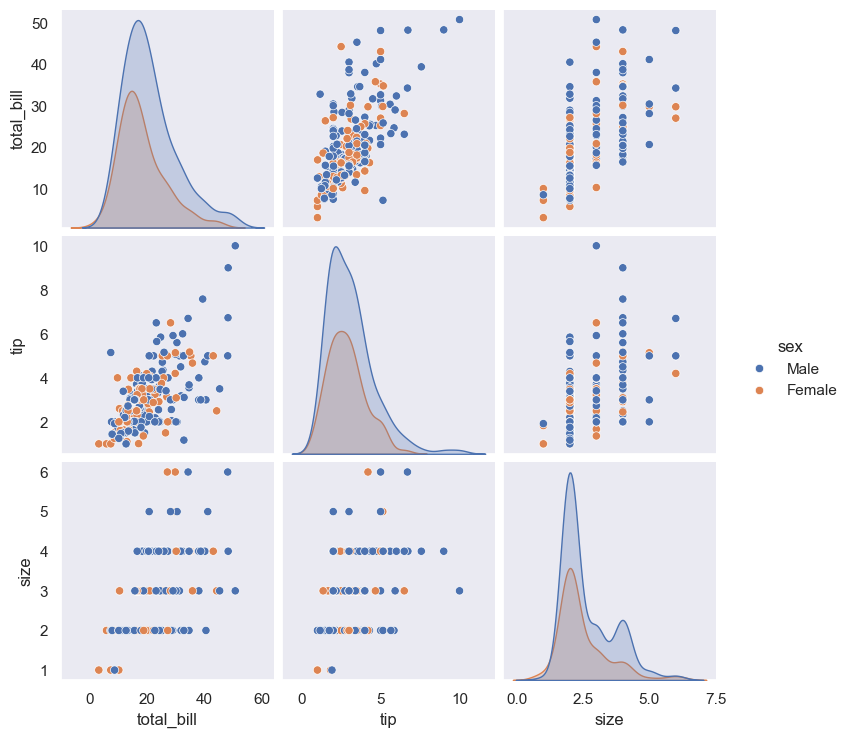

In [98]:
sns.pairplot(
    data = df,
    hue = "sex"
)

***17. Joint Plot***

creates a multi-panel figure to display both the joint relationship between two variables and their univariate distributions on the margins

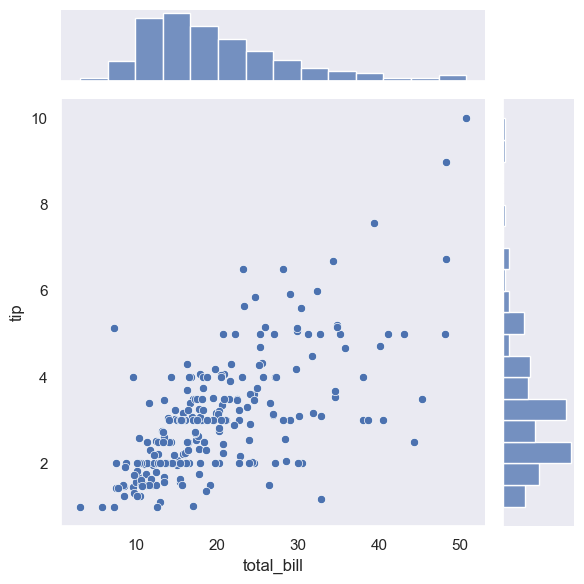

In [103]:
sns.jointplot(
    data = df,
    x = "total_bill",
    y = "tip",
)
plt.tight_layout()

kde joint plot :

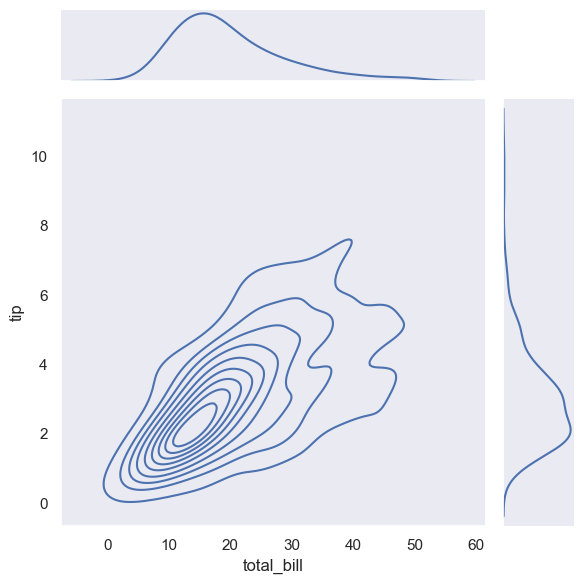

In [104]:
sns.jointplot(
    data = df,
    x = "total_bill",
    y = "tip",
    kind = "kde"
)
plt.tight_layout()

Hex Plot

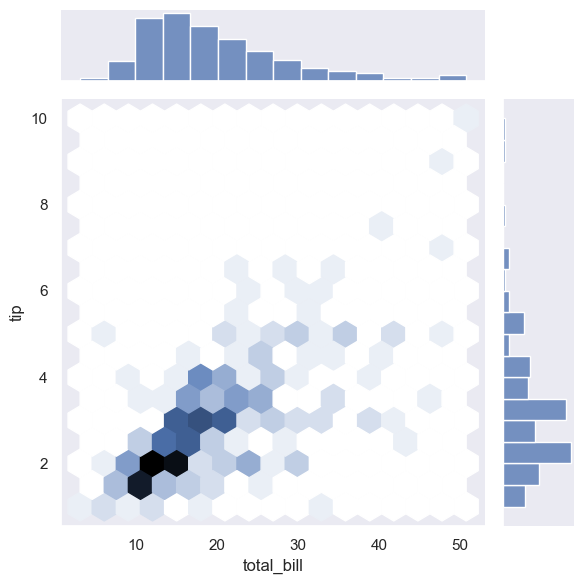

In [105]:
sns.jointplot(
    data = df,
    x = "total_bill",
    y = "tip",
    kind = "hex"
)
plt.tight_layout()

Facet Grids

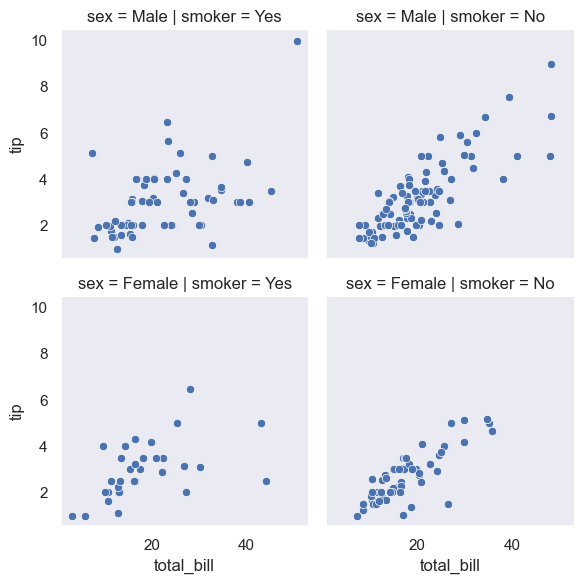

In [106]:
g = sns.FacetGrid(df, row = "sex", col = "smoker")

g.map(sns.scatterplot, "total_bill", "tip")

### annotate charts

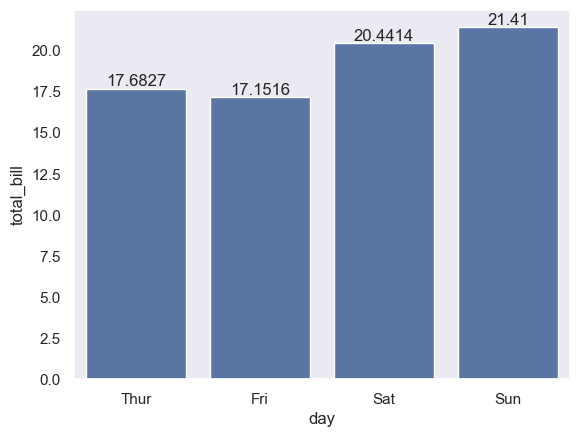

In [113]:
ax = sns.barplot(
    data = df,
    x = "day",
    y = "total_bill",
    errorbar = None
)

for container in ax.containers:
    ax.bar_label(
        container,
        label_type="edge"
        )
plt.show()